## 1. Query matched photometric and spectroscopic redshifts

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astroquery.esa.euclid import Euclid

project_root = Path(r"D:\AST\07_Euclid_Q1_Case_Study")

query = """
SELECT TOP 5000
    mer.object_id, mer.right_ascension, mer.declination, mer.flux_h_sersic,
    phz.phz_median,
    spe.spe_z, spe.spe_z_err, spe.spe_z_prob, spe.spe_z_rel, spe.spe_cont_snr,
    cls.spe_gal_prob,
    quality.spe_n_dith_med
FROM catalogue.mer_catalogue AS mer
INNER JOIN catalogue.phz_photo_z AS phz ON mer.object_id = phz.object_id
INNER JOIN catalogue.spectro_zcatalog_spe_galaxy_candidates AS spe ON mer.object_id = spe.object_id
INNER JOIN catalogue.spectro_zcatalog_spe_classification AS cls ON mer.object_id = cls.object_id
INNER JOIN catalogue.spectro_zcatalog_spe_quality AS quality ON mer.object_id = quality.object_id
WHERE spe.spe_rank = 0
    AND cls.spe_class = 'galaxy'
    AND quality.spe_error_flag = 0
    AND quality.spe_gal_error_flag = 0
    AND quality.spe_n_dith_med >= 3
    AND spe.spe_z > 0
    AND spe.spe_z_err > 0
    AND spe.spe_z_err < 0.1 * spe.spe_z
    AND phz.phz_median > 0
    AND phz.phz_median < 4
    AND mer.spurious_flag = 0
    AND mer.det_quality_flag = 0
"""

job = Euclid.launch_job_async(query, verbose=False)
photoz_specz_sample = job.get_results()

print("Matched high-quality galaxies:", len(photoz_specz_sample))
photoz_specz_sample[:10]

INFO: Query finished. [astroquery.utils.tap.core]
Matched high-quality galaxies: 5000


object_id,right_ascension,declination,flux_h_sersic,phz_median,spe_z,spe_z_err,spe_z_prob,spe_z_rel,spe_cont_snr,spe_gal_prob,spe_n_dith_med
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
-516569714297423600,51.65697145588476,-29.742360010757345,5.473252296447754,1.809999942779541,1.0259735584259033,0.0006655572797171772,0.9992429614067078,0.9944182634353638,--,1.0,3
-514580897294800276,51.45808977172403,-29.480027689530253,332.9653625488281,0.5400000214576721,0.012831962667405605,0.0002660161699168384,0.5351303219795227,0.30240797996520996,573.9244995117188,1.0,3
-516760189297394249,51.67601899459458,-29.73942493443034,8.713338851928711,0.3700000047683716,4.769874572753906,0.007305428385734558,0.9918346405029297,0.9145611524581909,27.901010513305664,1.0,3
-516727965297413777,51.67279655109469,-29.74137776289664,10.104278564453125,1.2200000286102295,0.9856579899787903,0.0007594883209094405,0.6808410286903381,0.42582380771636963,--,1.0,3
-516720360297346471,51.672036049666396,-29.734647164331708,12.559686660766602,0.4399999976158142,4.144099712371826,0.003936879336833954,0.980381429195404,0.5760757923126221,4.176647186279297,0.9985889792442322,3
-516371072297332825,51.63710723418377,-29.733282547003963,14.674249649047852,0.8500000238418579,0.9407030940055847,0.0013960575452074409,0.9945389628410339,0.3393577039241791,--,1.0,4
-516276918297343979,51.62769180526548,-29.734397924930803,11.586329460144043,0.550000011920929,1.6032230854034424,0.0025361166335642338,0.9521517157554626,0.7826313972473145,--,1.0,4
-515978499297340837,51.597849914552775,-29.734083723665925,12.784738540649414,0.6700000166893005,1.063596487045288,0.0007932853768579662,0.8517659306526184,0.15196557343006134,--,1.0,4
-515953217297355407,51.59532174652065,-29.73554073812812,5.592836380004883,0.949999988079071,0.8307950496673584,0.0005741695058532059,0.9558382034301758,0.13466008007526398,--,1.0,4


## 2. Compute photometric-redshift validation metrics

In [5]:
query_reached_limit = len(photoz_specz_sample) == 5000
validation_df = photoz_specz_sample.to_pandas()

numeric_columns = ["phz_median", "spe_z", "spe_z_err", "spe_z_prob", "spe_z_rel", "spe_cont_snr", "spe_gal_prob", "spe_n_dith_med"]
for column in numeric_columns:
    validation_df[column] = pd.to_numeric(validation_df[column], errors="coerce")

validation_df = validation_df.dropna(subset=["object_id", "phz_median", "spe_z"]).drop_duplicates("object_id").copy()
validation_df = validation_df[validation_df["spe_z"].between(0, 4, inclusive="neither")].copy()
validation_df["delta_z_normalized"] = (validation_df["phz_median"] - validation_df["spe_z"]) / (1 + validation_df["spe_z"])
validation_df["is_catastrophic_outlier"] = np.abs(validation_df["delta_z_normalized"]) > 0.15

high_reliability_df = validation_df[(validation_df["spe_z_prob"] >= 0.99) & (validation_df["spe_z_rel"] >= 0.99)].copy()

if len(high_reliability_df) == 0:
    raise ValueError("No high-reliability objects were found.")

def summarize_redshift_errors(data):
    errors = data["delta_z_normalized"].to_numpy()
    bias = np.median(errors)
    return pd.Series({
        "galaxies": len(data),
        "bias": bias,
        "nmad": 1.48 * np.median(np.abs(errors - bias)),
        "rmse": np.sqrt(np.mean(errors ** 2)),
        "outlier_percent": 100 * np.mean(np.abs(errors) > 0.15),
    })

metrics_table = pd.DataFrame({
    "quality_selected": summarize_redshift_errors(validation_df),
    "high_reliability": summarize_redshift_errors(high_reliability_df),
}).T

print("Query reached TOP 5000 limit:", query_reached_limit)
print("Objects after 0 < z_spec < 4:", len(validation_df))
print("High-reliability objects:", len(high_reliability_df))
metrics_table

Query reached TOP 5000 limit: True
Objects after 0 < z_spec < 4: 4617
High-reliability objects: 532


,galaxies,bias,nmad,rmse,outlier_percent
quality_selected,4617.0,-0.268653,0.278849,0.375828,75.113710
high_reliability,532.0,-0.438559,0.187138,0.459405,87.781955


## 3. Test the nominal NISP spectroscopic-redshift range

In [6]:
target_range_df = validation_df[validation_df["spe_z"].between(0.9, 1.8, inclusive="both")].copy()
target_high_reliability_df = target_range_df[(target_range_df["spe_z_prob"] >= 0.99) & (target_range_df["spe_z_rel"] >= 0.99)].copy()

target_metrics = pd.DataFrame({
    "target_range": summarize_redshift_errors(target_range_df),
    "target_high_reliability": summarize_redshift_errors(target_high_reliability_df),
}).T

comparison_metrics = pd.concat([metrics_table, target_metrics])
comparison_metrics = comparison_metrics.rename(columns={"outlier_percent": "large_disagreement_percent"})

print("Target-range objects:", len(target_range_df))
print("Target-range high-reliability objects:", len(target_high_reliability_df))
comparison_metrics

Target-range objects: 2903
Target-range high-reliability objects: 151


,galaxies,bias,nmad,rmse,large_disagreement_percent
quality_selected,4617.0,-0.268653,0.278849,0.375828,75.113710
high_reliability,532.0,-0.438559,0.187138,0.459405,87.781955
target_range,2903.0,-0.220556,0.239908,0.301589,68.480882
target_high_reliability,151.0,-0.232108,0.239241,0.305373,65.562914


## 4. Visualise and save the PHZ–SPE disagreement

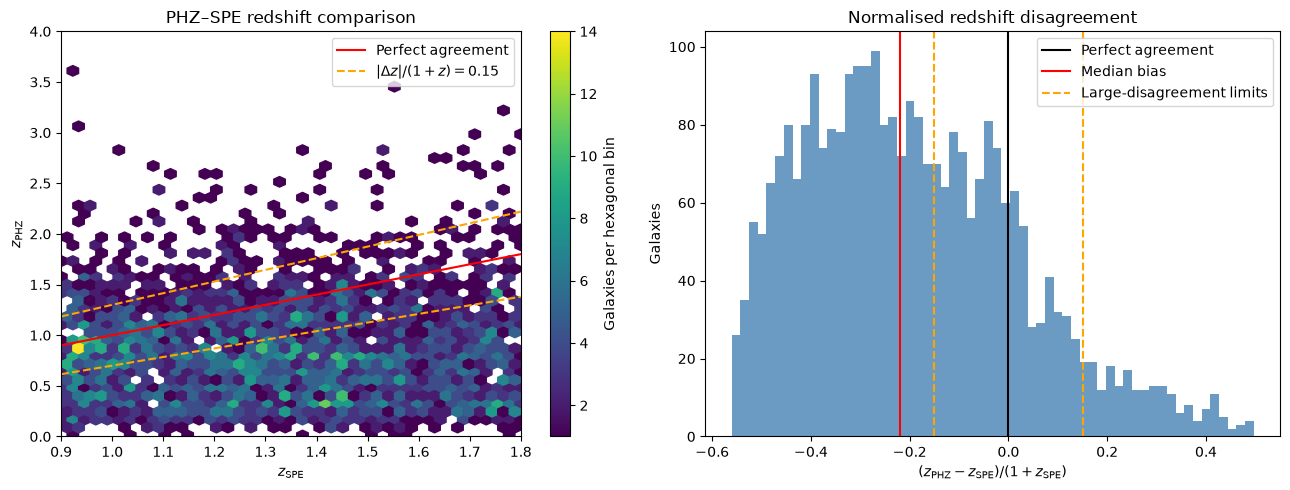

Saved figure: D:\AST\07_Euclid_Q1_Case_Study\outputs\figures\photoz_spe_disagreement_diagnostic.png
Saved matched sample: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\photoz_spe_matched_sample.csv
Saved metrics: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\photoz_spe_comparison_metrics.csv


In [7]:
redshift_grid = np.linspace(0.9, 1.8, 300)
upper_disagreement_limit = redshift_grid + 0.15 * (1 + redshift_grid)
lower_disagreement_limit = redshift_grid - 0.15 * (1 + redshift_grid)

error_low, error_high = target_range_df["delta_z_normalized"].quantile([0.01, 0.99])

figure_output_path = project_root / "outputs" / "figures" / "photoz_spe_disagreement_diagnostic.png"
sample_output_path = project_root / "outputs" / "tables" / "photoz_spe_matched_sample.csv"
metrics_output_path = project_root / "outputs" / "tables" / "photoz_spe_comparison_metrics.csv"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

density = axes[0].hexbin(target_range_df["spe_z"], target_range_df["phz_median"], gridsize=40, mincnt=1, cmap="viridis")
axes[0].plot(redshift_grid, redshift_grid, color="red", label="Perfect agreement")
axes[0].plot(redshift_grid, upper_disagreement_limit, color="orange", linestyle="--", label=r"$|\Delta z|/(1+z)=0.15$")
axes[0].plot(redshift_grid, lower_disagreement_limit, color="orange", linestyle="--")
axes[0].set(xlim=(0.9, 1.8), ylim=(0, 4), xlabel=r"$z_{\mathrm{SPE}}$", ylabel=r"$z_{\mathrm{PHZ}}$", title="PHZ–SPE redshift comparison")
axes[0].legend()
fig.colorbar(density, ax=axes[0], label="Galaxies per hexagonal bin")

axes[1].hist(target_range_df["delta_z_normalized"], bins=60, range=(error_low, error_high), color="steelblue", alpha=0.8)
axes[1].axvline(0, color="black", label="Perfect agreement")
axes[1].axvline(target_metrics.loc["target_range", "bias"], color="red", label="Median bias")
axes[1].axvline(-0.15, color="orange", linestyle="--", label="Large-disagreement limits")
axes[1].axvline(0.15, color="orange", linestyle="--")
axes[1].set(xlabel=r"$(z_{\mathrm{PHZ}}-z_{\mathrm{SPE}})/(1+z_{\mathrm{SPE}})$", ylabel="Galaxies", title="Normalised redshift disagreement")
axes[1].legend()

fig.tight_layout()
fig.savefig(figure_output_path, dpi=300, bbox_inches="tight")
plt.show()

validation_df.to_csv(sample_output_path, index=False)
comparison_metrics.to_csv(metrics_output_path)

print("Saved figure:", figure_output_path)
print("Saved matched sample:", sample_output_path)
print("Saved metrics:", metrics_output_path)

In [3]:
print("！WARNING: outlier fraction is unusually. "
      "Root cause unclear — maybe a SQL query issue (duplicate/mismatched JOIN, non-unique spe_rank=0). Further investigation required.")

！WARNING: outlier fraction is unusually. Root cause unclear — maybe a SQL query issue (duplicate/mismatched JOIN, non-unique spe_rank=0). Further investigation required.
